In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())   # Must print True
print("GPU:", torch.cuda.get_device_name(0))          # Should print RTX 4050

CUDA available: True
GPU: NVIDIA H100 NVL


In [6]:
import os
import shutil
from pathlib import Path
from torchvision.datasets import Food101
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from ultralytics import YOLO
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch
import matplotlib

In [ ]:
script_dir = os.path.dirname(os.path.abspath(__file__))
data_root = os.path.join(script_dir, '..', 'data')
FOOD101_IMG_DIR = Path(script_dir) / '..' / 'data' / 'food-101' / 'images'
YOLO_DIR        = Path(script_dir) / '..' / 'data' / 'yolo_food101'
META_DIR        = Path(script_dir) / '..' / 'data' / 'food-101' / 'meta'
PROJECT         = os.path.join(script_dir,'..', 'outputs/yolo/runs/classify')
results_csv_path         = os.path.join(script_dir,'..', 'outputs/yolo/runs/classify/yolov8s_food101/results.csv')
best_model_path         = os.path.join(script_dir,'..', 'outputs/yolo/runs/classify/yolov8s_food101/weights/best.pt')
saved_model_path         = os.path.join(script_dir,'..', 'models/yolo/saved_models/yolov8s_food101.pt')
output_image_path         = os.path.join(script_dir,'..', 'outputs/yolo/images/yolov8_training_curves.png')

In [7]:
dummy_transform = transforms.ToTensor()
train_dataset = Food101(root=data_root, split='train', download=True, transform=dummy_transform)
test_dataset  = Food101(root=data_root, split='test',  download=True, transform=dummy_transform)

print(f"Train size: {len(train_dataset)}")
print(f"Test size:  {len(test_dataset)}")
print(f"Classes:    {len(train_dataset.classes)}")

Train size: 75750
Test size:  25250
Classes:    101


In [8]:
# YOLOv8 needs this exact folder layout:
#
# yolo_food101/
#   train/
#     apple_pie/  <- images here
#     baby_back_ribs/
#     ...
#   val/
#     apple_pie/
#     ...
#
# We use symlinks so we don't duplicate 4GB of data

def read_split(split_file):
    with open(split_file) as f:
        return [l.strip() for l in f.readlines()]

train_items = read_split(META_DIR / 'train.txt')
test_items  = read_split(META_DIR / 'test.txt')

print(f"Train items: {len(train_items)}")
print(f"Test  items: {len(test_items)}")

for split, items in [('train', train_items), ('val', test_items)]:
    for item in items:
        class_name, img_name = item.split('/')
        dest_dir = YOLO_DIR / split / class_name
        dest_dir.mkdir(parents=True, exist_ok=True)
        src  = (FOOD101_IMG_DIR / class_name / (img_name + '.jpg')).resolve()
        dest = (dest_dir / (img_name + '.jpg')).resolve()
        if not dest.exists():
            try:
                os.symlink(src, dest)
            except Exception:
                shutil.copy2(src, dest)  # fallback if symlink fails on Windows

print("\nYOLO dataset folder structure ready!")
print(f"Location: {YOLO_DIR.resolve()}")

Train items: 75750
Test  items: 25250

YOLO dataset folder structure ready!
Location: C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101


In [9]:
# yolov8s-cls = small YOLOv8 classification model (recommended for RTX 4050)
# weights=None equivalent: using .yaml builds from scratch (no pretrained weights)
# This keeps the comparison fair with AlexNet and ResNet

model = YOLO('yolov8s-cls.yaml')  # from scratch

results = model.train(
    data=str(YOLO_DIR.resolve()),
    epochs=60,
    imgsz=224,           # same image size as ResNet34/50
    batch=64,            # same batch size as AlexNet/ResNet
    device=0,            # RTX 4050
    patience=5,          # early stopping — same as AlexNet/ResNet
    workers=4,
    project=PROJECT,
    name='yolov8s_food101',
    exist_ok=True,
    verbose=True
)

print("\nTraining complete!")
print("Best model saved at: runs/classify/yolov8s_food101/weights/best.pt")

YOLOv8s-cls summary: 56 layers, 6,361,736 parameters, 6,361,736 gradients, 13.6 GFLOPs
Ultralytics 8.4.70  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.yaml, momentu

C:\Users\chira\Downloads\Dissertation\Code\dissertation_env\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


train: Scanning C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\train... 75750 images, 0 corrupt: 100% ━━━━━━━━━━━━ 75750/75750 2.0Kit/s 37.1s0.0ss
train: New cache created: C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\train.cache
val: Fast image access  (ping: 0.20.0 ms, read: 21.817.2 MB/s, size: 37.4 KB)
val: Scanning C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\val... 25250 images, 0 corrupt: 100% ━━━━━━━━━━━━ 25250/25250 2.1Kit/s 11.9s0.0s
val: New cache created: C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: MuSGD(lr=0.01, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 4 dataloader workers
Logging results to C:\Users\chira\Downloads\Dissertation\Code\YOLOv8

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



       6/60      1.54G      2.058         38        224: 100% ━━━━━━━━━━━━ 1184/1184 4.1it/s 4:500.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 198/198 3.8it/s 52.5s0.1ss
                   all      0.662       0.89

      Epoch    GPU_mem       loss  Instances       Size
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 198/198 3.7it/s 53.0s0.1ss 3:00<1:277
                   all      0.697      0.908

      Epoch    GPU_mem       loss  Instances       Size
       8/60      1.54G      1.771         38        224: 100% ━━━━━━━━━━━━ 1184/1184 4.4it/s 4:300.2ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 198/198 3.8it/s 52.0s0.1ss
                   all      0.724      0.923

      Epoch    GPU_mem       loss  Instances       Size
       9/60      1.54G      1.673         38        224: 100% ━━━━━━━━━━━━ 1184/1184 4.3it/s 4:320.3ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 198/198 3.5it/s 56.7s0.3ss
           

Available columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


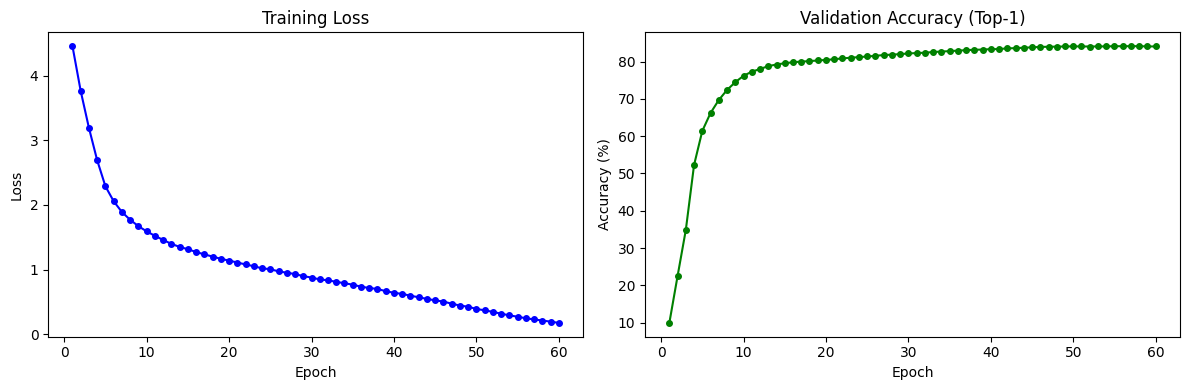


Best Top-1 Accuracy: 84.13%


In [45]:
matplotlib.use('Agg')

results_csv = results_csv_path
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

print("Available columns:", df.columns.tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['epoch'], df['train/loss'], 'b-o', markersize=4)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(df['epoch'], df['metrics/accuracy_top1'] * 100, 'g-o', markersize=4)
ax2.set_title('Validation Accuracy (Top-1)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig(output_image_path, dpi=150)
plt.show()

best_acc = df['metrics/accuracy_top1'].max() * 100
print(f"\nBest Top-1 Accuracy: {best_acc:.2f}%")

In [46]:
best_model = YOLO(best_model_path)

metrics = best_model.val(
    data=str(YOLO_DIR.resolve()),
    split='val',
    imgsz=224,
    batch=64,
    device=0
)

print(f"\nTop-1 Accuracy: {metrics.top1 * 100:.2f}%")
print(f"Top-5 Accuracy: {metrics.top5 * 100:.2f}%")

Ultralytics 8.4.70  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,204,581 parameters, 0 gradients, 12.6 GFLOPs
train: C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\train... found 75750 images in 101 classes  
val: C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\val... found 25250 images in 101 classes  
test: None...
val: Fast image access  (ping: 0.20.0 ms, read: 59.814.3 MB/s, size: 37.4 KB)
val: Scanning C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\yolo_food101\val... 25250 images, 0 corrupt: 100% ━━━━━━━━━━━━ 25250/25250  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 395/395 6.4it/s 1:02<0.1sss
                   all      0.841      0.964
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\chira\Downloads\Dissertation\Code\YOLOv8\runs\classify\val

Top-1 Accuracy: 84.13%
Top-5 Accuracy: 

In [47]:
shutil.copy(best_model_path, saved_model_path)
print("Model saved to saved_models/yolov8s_food101.pt")

Model saved to saved_models/yolov8s_food101.pt


In [48]:
model_reload = YOLO(saved_model_path)
print("Model loaded successfully!")

Model loaded successfully!
